In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import time

In [ ]:
df = pd.read_csv("Dry_Bean_Dataset.csv")

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
print("Shape of dataset:", df.shape)

Shape of dataset: (13611, 17)


In [ ]:
print(df.columns)

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 68


In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (13543, 17)


In [ ]:
print(df["Class"].unique())

['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


In [ ]:
print(df["Class"].value_counts())

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


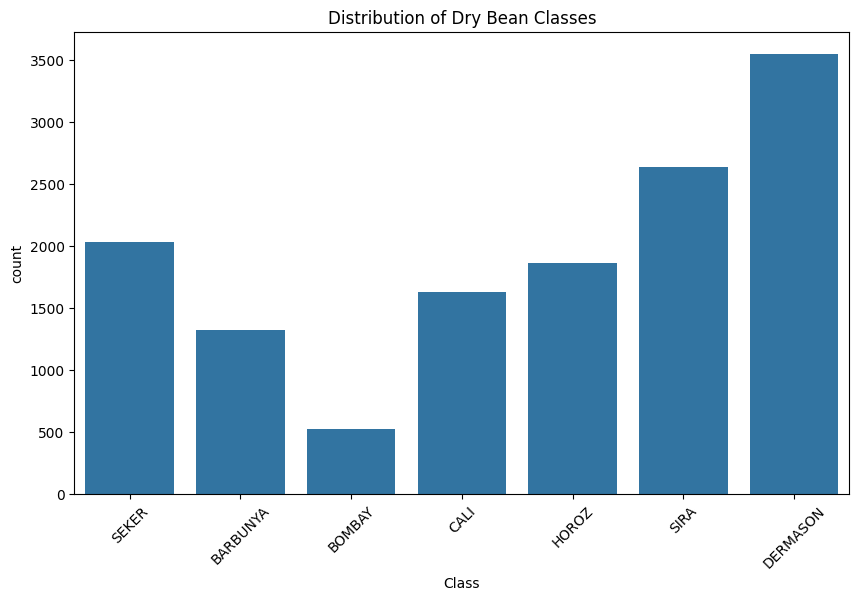

In [ ]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Dry Bean Classes")
plt.xticks(rotation=45)
plt.show()

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def evaluate_model(model, kernel_name):

    start_time = time.time()

    model.fit(X_train_scaled, y_train)

    end_time = time.time()

    training_time = end_time - start_time

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, average="weighted", zero_division=0
    )

    print("\n", "="*50)
    print(kernel_name)
    print("="*50)

    print("Training Time:", training_time, "seconds")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    return {
        "Kernel": kernel_name,
        "Training Time": training_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Model": model
    }

In [ ]:
linear_model = SVC(
    kernel="linear",
    C=1
)

linear_result = evaluate_model(
    linear_model,
    "Linear Kernel"
)


Linear Kernel
Training Time: 1.1889047622680664 seconds
Accuracy: 0.9210040605389442
Precision: 0.9210980490566268
Recall: 0.9210040605389442
F1 Score: 0.921000755078614


In [ ]:
poly_model = SVC(
    kernel="poly",
    C=1,
    gamma="scale",
    degree=3
)

poly_result = evaluate_model(
    poly_model,
    "Polynomial Kernel"
)


Polynomial Kernel
Training Time: 2.016331195831299 seconds
Accuracy: 0.9139904023624954
Precision: 0.921894058327863
Recall: 0.9139904023624954
F1 Score: 0.9154916986351318


In [ ]:
rbf_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

rbf_result = evaluate_model(
    rbf_model,
    "RBF Kernel"
)


RBF Kernel
Training Time: 3.056675910949707 seconds
Accuracy: 0.9210040605389442
Precision: 0.9214106079511519
Recall: 0.9210040605389442
F1 Score: 0.9210779160652252


In [ ]:
sigmoid_model = SVC(
    kernel="sigmoid",
    C=1,
    gamma="scale"
)

sigmoid_result = evaluate_model(
    sigmoid_model,
    "Sigmoid Kernel"
)


Sigmoid Kernel
Training Time: 4.297844409942627 seconds
Accuracy: 0.7305278700627538
Precision: 0.7714475497504677
Recall: 0.7305278700627538
F1 Score: 0.7465119444018572


In [ ]:
results = [
    linear_result,
    poly_result,
    rbf_result,
    sigmoid_result
]

results_df = pd.DataFrame(results)

results_df = results_df.drop(columns=["Model"])

results_df

,Kernel,Training Time,Accuracy,Precision,Recall,F1 Score
0,Linear Kernel,1.188905,0.921004,0.921098,0.921004,0.921001
1,Polynomial Kernel,2.016331,0.913990,0.921894,0.913990,0.915492
2,RBF Kernel,3.056676,0.921004,0.921411,0.921004,0.921078
3,Sigmoid Kernel,4.297844,0.730528,0.771448,0.730528,0.746512


In [ ]:
C_values = [0.1, 1, 10, 100]

C_results = []

for C in C_values:

    model = SVC(
        kernel="rbf",
        C=C,
        gamma="scale"
    )

    start_time = time.time()

    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start_time

    y_pred = model.predict(X_test_scaled)

    C_results.append({
        "C": C,
        "Training Time": training_time,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        )
    })

C_results_df = pd.DataFrame(C_results)

C_results_df

,C,Training Time,Accuracy,Precision,Recall,F1 Score
0,0.1,2.884556,0.917682,0.919001,0.917682,0.917921
1,1.0,1.279393,0.921004,0.921411,0.921004,0.921078
2,10.0,1.233955,0.923588,0.923764,0.923588,0.923622
3,100.0,1.966687,0.922850,0.923009,0.922850,0.922832


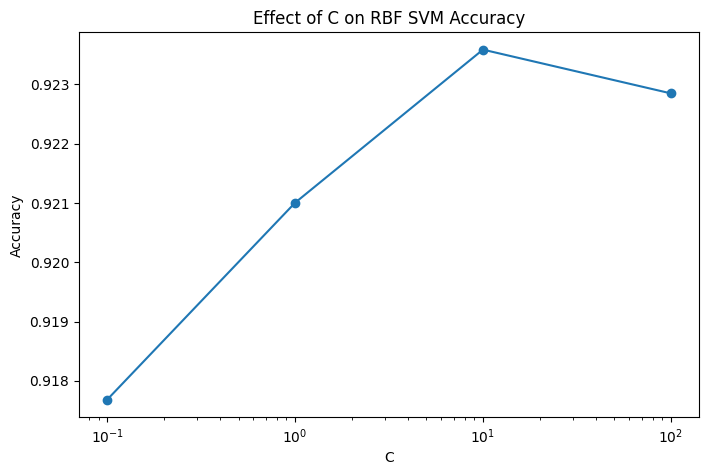

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    C_results_df["C"],
    C_results_df["Accuracy"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Effect of C on RBF SVM Accuracy")

plt.show()

In [ ]:
gamma_values = [0.001, 0.01, 0.1, 1]

gamma_results = []

for gamma in gamma_values:

    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma
    )

    start_time = time.time()

    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start_time

    y_pred = model.predict(X_test_scaled)

    gamma_results.append({
        "Gamma": gamma,
        "Training Time": training_time,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        )
    })

gamma_results_df = pd.DataFrame(gamma_results)

gamma_results_df

,Gamma,Training Time,Accuracy,Precision,Recall,F1 Score
0,0.001,2.910617,0.909930,0.912224,0.909930,0.910274
1,0.010,0.885758,0.919158,0.919951,0.919158,0.919329
2,0.100,1.254209,0.923588,0.924018,0.923588,0.923699
3,1.000,5.534938,0.917313,0.917695,0.917313,0.917347


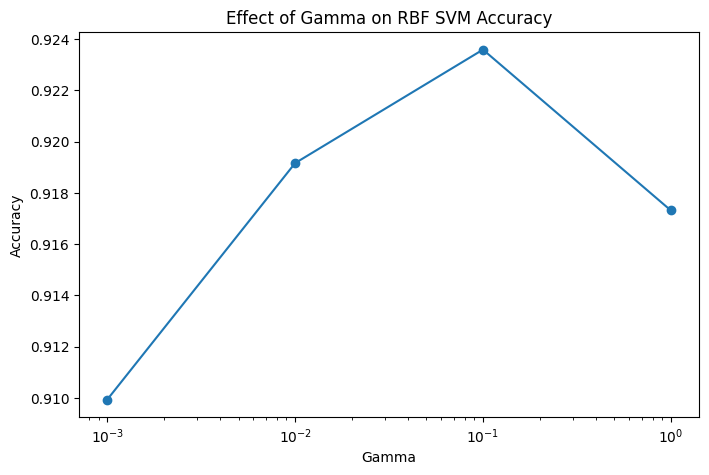

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    gamma_results_df["Gamma"],
    gamma_results_df["Accuracy"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.title("Effect of Gamma on RBF SVM Accuracy")

plt.show()

In [ ]:
degree_values = [2, 3, 4, 5]

degree_results = []

for degree in degree_values:

    model = SVC(
        kernel="poly",
        C=1,
        gamma="scale",
        degree=degree
    )

    start_time = time.time()

    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start_time

    y_pred = model.predict(X_test_scaled)

    degree_results.append({
        "Degree": degree,
        "Training Time": training_time,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        )
    })

degree_results_df = pd.DataFrame(degree_results)

degree_results_df

,Degree,Training Time,Accuracy,Precision,Recall,F1 Score
0,2,2.939014,0.913990,0.917871,0.913990,0.914749
1,3,1.425770,0.913990,0.921894,0.913990,0.915492
2,4,4.399208,0.861942,0.880811,0.861942,0.863420
3,5,1.789937,0.854190,0.893384,0.854190,0.860013


In [ ]:
models = {
    "Linear": linear_model,
    "Polynomial": poly_model,
    "RBF": rbf_model,
    "Sigmoid": sigmoid_model
}

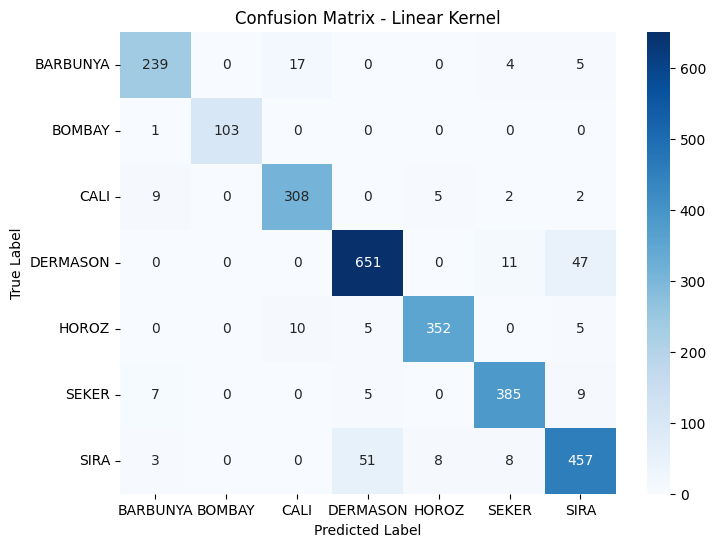

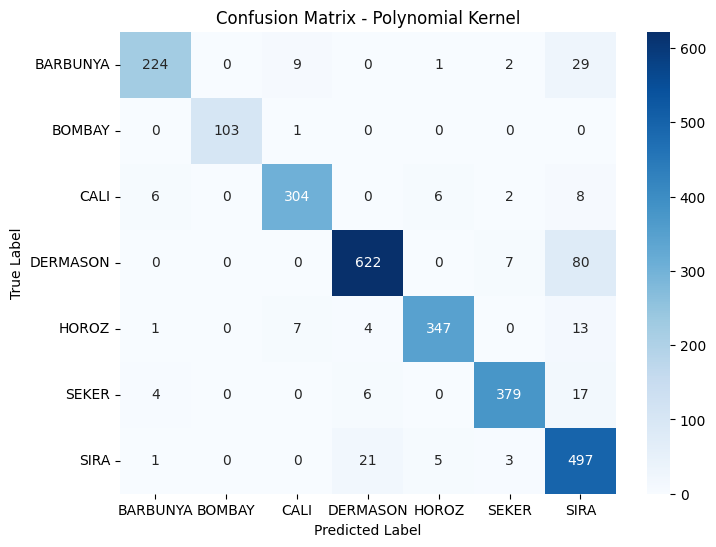

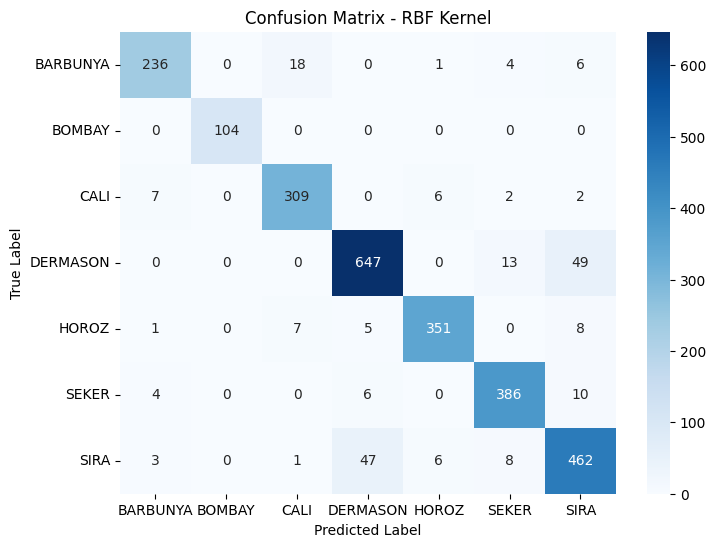

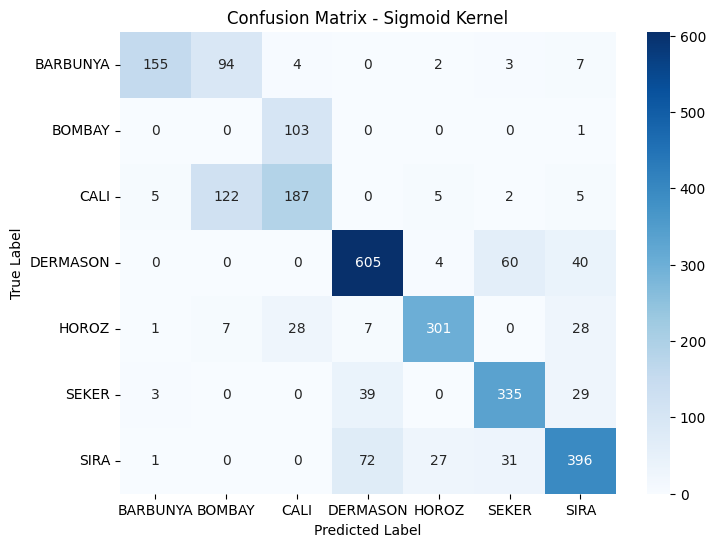

In [ ]:
for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=model.classes_,
        yticklabels=model.classes_
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {name} Kernel")

    plt.show()

In [ ]:
best_model = rbf_model

y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.95      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



In [ ]:
best_kernel = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best Kernel:")
print(best_kernel)

Best Kernel:
Kernel           RBF Kernel
Training Time      3.056676
Accuracy           0.921004
Precision          0.921411
Recall             0.921004
F1 Score           0.921078
Name: 2, dtype: object


In [ ]:
final_comparison = results_df[
    [
        "Kernel",
        "Training Time",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
]

print(final_comparison)

              Kernel  Training Time  Accuracy  Precision    Recall  F1 Score
0      Linear Kernel       1.188905  0.921004   0.921098  0.921004  0.921001
1  Polynomial Kernel       2.016331  0.913990   0.921894  0.913990  0.915492
2         RBF Kernel       3.056676  0.921004   0.921411  0.921004  0.921078
3     Sigmoid Kernel       4.297844  0.730528   0.771448  0.730528  0.746512


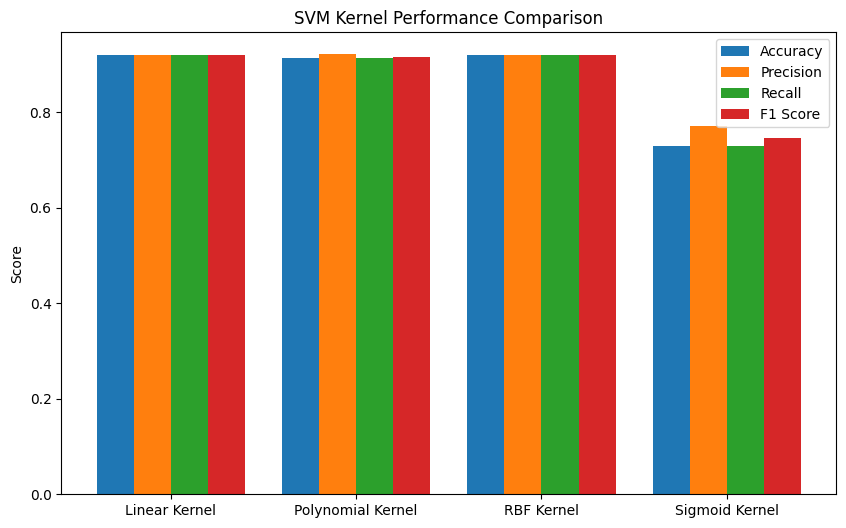

In [ ]:
plt.figure(figsize=(10, 6))

x = np.arange(len(results_df["Kernel"]))
width = 0.2

plt.bar(
    x - 1.5*width,
    results_df["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x - 0.5*width,
    results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + 0.5*width,
    results_df["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + 1.5*width,
    results_df["F1 Score"],
    width,
    label="F1 Score"
)

plt.xticks(x, results_df["Kernel"])

plt.ylabel("Score")
plt.title("SVM Kernel Performance Comparison")

plt.legend()

plt.show()

After doing all the steps and testing various models, the RBF kernel achieved the highest F1-score and gave the best overall classification performance.confusion matrix also indicates that it was able to distinguish all of the seven bean classes effectively. The Linear kernel had lower computational complexity, while the nonlinear kernels were able to model more complex relationships in the features. Among the hyperparameters, changing C affected the trade-off between classification errors and model complexity, while gamma controlled the influence of individual training samples. For the Polynomial kernel,change in the degree also affected the complexity of the decision boundary. Overall, the RBF kernel provided the best balance between predictive performance and training time for this dataset.